# DINOv3 dense correspondences (nuScenes-friendly)

This notebook adapts the official [DINOv3 dense/sparse matching tutorial](https://github.com/facebookresearch/dinov3/blob/main/notebooks/dense_sparse_matching.ipynb)
so you can visualize cross-view correspondences with the lightweight wrappers in this repository. It downloads two example images,
extracts patch-level features with `DinoImageEncoder`, and plots the strongest matches using `DinoMatcher`.


In [2]:
import io
import urllib.request
from pathlib import Path

from PIL import Image
from nuscenes_dino import DinoImageEncoder, DinoMatcher, plot_correspondences


In [3]:
# Download the sample images from the official DINOv3 notebook.
left_url = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_left.jpg"
right_url = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_right.jpg"

left_img = Image.open(io.BytesIO(urllib.request.urlopen(left_url).read())).convert("RGB")
right_img = Image.open(io.BytesIO(urllib.request.urlopen(right_url).read())).convert("RGB")

left_img, right_img

(<PIL.Image.Image image mode=RGB size=2272x2141>,
 <PIL.Image.Image image mode=RGB size=4032x3024>)

In [4]:
# Build the encoder/matcher. Set `device="cuda"` or `device_map="auto"` for GPU boxes.
encoder = DinoImageEncoder()
matcher = DinoMatcher(encoder)

# Extract dense patch features for both images.
left_map, right_map = matcher.extract_dense_maps([left_img, right_img])

# Retrieve the strongest correspondences.
matches = matcher.match(left_map, right_map, top_k=50)
len(matches)

ValueError: Model output is not a square grid; cannot reshape into dense map.

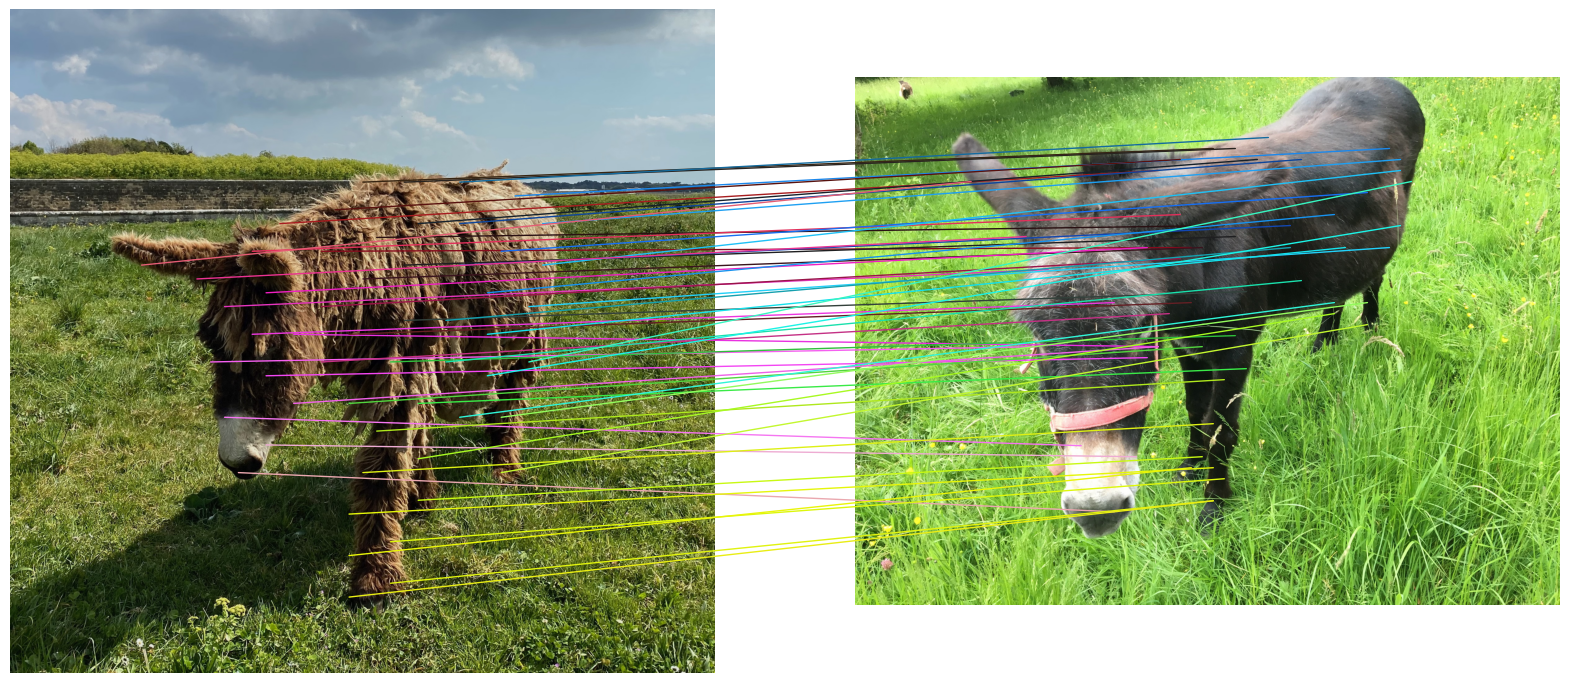

In [ ]:
# Visualize the matches (this returns a matplotlib Figure).
fig = plot_correspondences(left_img, right_img, matches, max_lines=30)
fig